Importing the data

In [1]:
import pandas as pd

df = pd.read_csv("bank.csv")
print(df.shape)
print(df.head())

(11162, 17)
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [2]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [3]:
print(df['job'].value_counts())


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


In [4]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)


In [5]:
print(df['education'].unique())

<StringArray>
['secondary', 'tertiary', 'primary', 'unknown']
Length: 4, dtype: str


In [6]:
import numpy as np

df = df.replace("unknown", np.nan)

In [7]:
print(df.isnull().sum())

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


In [8]:
df['default'] = df['default'].map({"yes": 1, "no": 0})

In [9]:
print(df['housing'].value_counts())

housing
no     5881
yes    5281
Name: count, dtype: int64


In [10]:
df['housing'] = df['housing'].map({"yes": 1, "no": 0})

In [11]:
print(df['loan'].value_counts())

loan
no     9702
yes    1460
Name: count, dtype: int64


In [12]:
df['loan'] = df['loan'].map({"yes": 1, "no": 0})

In [13]:
print(df.isnull().sum())

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64


FOR CONTACT TOO MUCH DATA IS MISSING TO JUST FILL WITH MODE SO WE  REPLACE THE NAN WITH UNKNOWN AND LET IT BE OWN CATEGORY DURING OHE

In [14]:
df['contact'] = df['contact'].fillna('unknown')

In [15]:
df = df.drop(columns=['poutcome'])

In [16]:
print(df.head())

   age         job  marital  education  default  balance  housing  loan  \
0   59      admin.  married  secondary        0     2343        1     0   
1   56      admin.  married  secondary        0       45        0     0   
2   41  technician  married  secondary        0     1270        1     0   
3   55    services  married  secondary        0     2476        1     0   
4   54      admin.  married   tertiary        0      184        0     0   

   contact  day month  duration  campaign  pdays  previous deposit  
0  unknown    5   may      1042         1     -1         0     yes  
1  unknown    5   may      1467         1     -1         0     yes  
2  unknown    5   may      1389         1     -1         0     yes  
3  unknown    5   may       579         1     -1         0     yes  
4  unknown    5   may       673         2     -1         0     yes  


In [17]:
print(df['deposit'].value_counts())

deposit
no     5873
yes    5289
Name: count, dtype: int64


In [18]:
df["deposit"] = df['deposit'].map({"yes":1 , "no":0})

In [19]:
from sklearn.model_selection import train_test_split

df_org = df.copy()
X = df.drop(columns=['deposit'])
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
mod_val = X_train['job'].mode()[0]
X_train['job'] = X_train['job'].fillna(mod_val)
X_test['job'] = X_test['job'].fillna(mod_val)

In [21]:
e_mod_val = X_train['education'].mode()[0]
X_train['education'] = X_train['education'].fillna(e_mod_val)
X_test['education'] = X_test['education'].fillna(e_mod_val)

LETS TRY TO VISUALIZE THIS THING

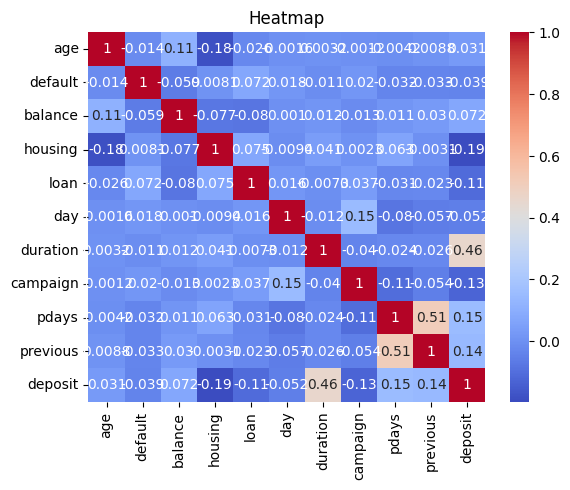

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

viz_df = pd.concat([X_train, y_train], axis= 1)
corr = viz_df.select_dtypes(include = 'number').corr()
sns.heatmap(corr, annot = True, cmap =  'coolwarm')
plt.title("Heatmap")
plt.show()

In [23]:
viz_df.select_dtypes(include='number').corr()['deposit'].sort_values(ascending = False)

deposit     1.000000
duration    0.455134
pdays       0.152436
previous    0.141661
balance     0.072000
age         0.031209
default    -0.038681
day        -0.051525
loan       -0.109854
campaign   -0.126892
housing    -0.194485
Name: deposit, dtype: float64

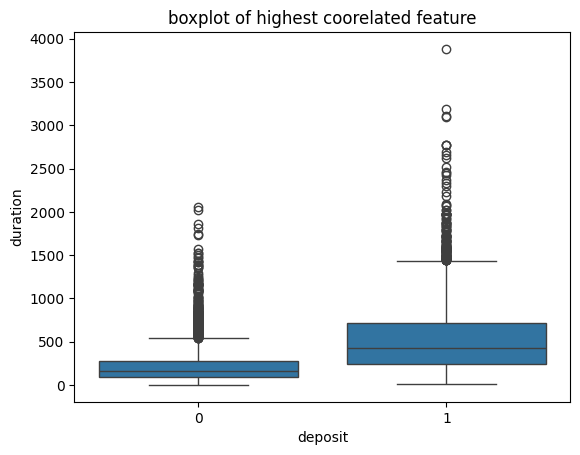

In [24]:
sns.boxplot(x = 'deposit', y = 'duration', data = viz_df)
plt.title("boxplot of highest coorelated feature")
plt.show()

TECHNICALLY CALL DURATION IS OBTAINED AFTER CALLING SO THIS WOULD BE DATA LEAKAGE IN THE REAL WORLD SO IN REAL THIS WOULD BE USELESS (KINDA CHEATING ) YOU'D HAVE TO DROP THIS IRL. we are keeping this for practice purposes.

In [25]:
print(X_train.head())

       age           job   marital  education  default  balance  housing  \
3955    28       student    single   tertiary        0     5741        0   
11150   34    management   married  secondary        0      355        0   
5173    48    unemployed  divorced  secondary        0      201        0   
3017    53  entrepreneur   married   tertiary        0     1961        0   
2910    53    management   married   tertiary        0     1624        0   

       loan   contact  day month  duration  campaign  pdays  previous  
3955      0  cellular   10   sep      1042         5    200         3  
11150     0  cellular   21   aug       314         3     -1         0  
5173      0  cellular   10   nov       594         1     91         1  
3017      0  cellular   15   dec       351         1     -1         0  
2910      0  cellular   11   nov       166         3     97         7  


In [26]:
print(df.select_dtypes(include='number').columns)

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration',
       'campaign', 'pdays', 'previous', 'deposit'],
      dtype='str')


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

NOW WE DO OHE

In [28]:
cols =  ['job', 'marital', 'education', 'contact', 'month']


In [29]:
X_train_scaled = pd.get_dummies(X_train_scaled, columns = cols, drop_first=True)
X_test_scaled = pd.get_dummies(X_test_scaled, columns = cols, drop_first=True)

X_train_scaled, X_test_scaled = X_train_scaled.align(X_test_scaled, join = 'left', axis = 1, fill_value= 0)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42), 
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    print(f"{name}: Test_acc: {test_acc}, Train_acc: {train_acc}")

Logistic Regression: Test_acc: 0.7989252127183162, Train_acc: 0.8195766603203046
Decision Tree: Test_acc: 0.7568293775190327, Train_acc: 1.0
Random Forest: Test_acc: 0.8351992834751455, Train_acc: 1.0


In [36]:
from sklearn.metrics import classification_report
for name, model in models.items():
    print(f"{name}: {classification_report(y_test, model.predict(X_test_scaled))}")

Logistic Regression:               precision    recall  f1-score   support

           0       0.80      0.83      0.81      1166
           1       0.80      0.77      0.79      1067

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233

Decision Tree:               precision    recall  f1-score   support

           0       0.76      0.78      0.77      1166
           1       0.75      0.73      0.74      1067

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233

Random Forest:               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1166
           1       0.81      0.86      0.83      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84

HERE RANDOM FOREST CLEARLY DEFEATS OTHERS EVEN IF IT OVERFIT 

In [39]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(models['Random Forest'], X_train_scaled, y_train, cv = 5, scoring= "accuracy")
print(f"score : {score.mean()} +/- {score.std()}")

score : 0.8517182192025746 +/- 0.0048764213653608515


In [40]:
rf_param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2,5]
}


In [41]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_param_grid, 
    cv = 5, 
    n_jobs= -1, 
    scoring="accuracy"
)

rf_grid.fit(X_train_scaled, y_train)
print(rf_grid.best_params_)
print(rf_grid.best_score_)
best_model = rf_grid.best_estimator_
print(best_model.score(X_test_scaled, y_test))

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
0.8544064165419807
0.8351992834751455


In [46]:
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1166
           1       0.80      0.87      0.83      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



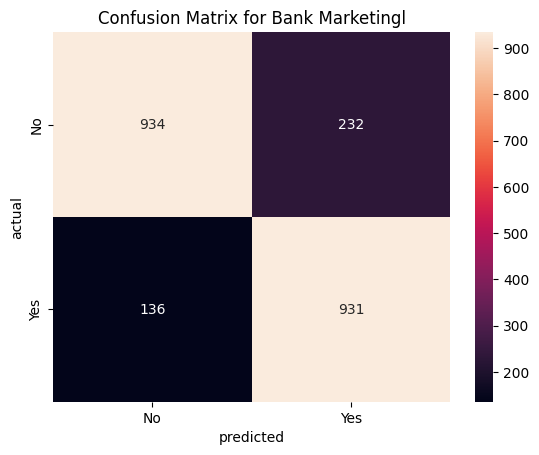

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix for Bank Marketingl")
plt.show()


In [48]:
import joblib

joblib.dump(best_model, "Bank_model.pkl")


['Bank_model.pkl']

In [50]:
loaded_model = joblib.load("Bank_model.pkl")
print(loaded_model.score(X_test_scaled, y_test))

0.8351992834751455
